# Eigendecomposition
---
Eigendecomposition is considered the heart of linear algebra.
Eigendecomposition has a geometric interpretation (axis of rotation invariance)
a statistical interpretation (axis of maximal covariance), a dynamical-systems interpretation (stable system states), a graph-theoretic
interpretation (the impact of a node on its network), a financial-market interpretation (identifying
stocks that covary), and many more.
Eigendecomposition (and the SVD, which we will cover later
and is closely related to eigendecomposition) is among the most important contributions of
algebra to data science.

**Geometry**: There is a special combination of matrix and a vector such that the matrix stretched but did not rotate vector. That vector is an eigenvector of the matrix, and the amount of stretching is eigenvalue.

**Statistics** (Principal Components Analysis):
We apply statistics to identity and quantity relationships
between variables. For example, the rise of global temperatures correlates with the decline in the number of birds, but how strong is that relationship? There are tens of thousands of cryptocoins and we can ask whether the entirety of
the cryptospace operates as a single system (meaning that the value of all coins gcup and down together), or whether there are independent subcategories within that space (meaning that some coins or groups of coins change in value independently of the value or other coins). Such hypothesis can be tested by
performing a principal components analysis on dataset that contains the prices of various cryptocoins over time.

**Noise Reduction**: Most datasets contain noise. One method of reducing random noise is to identity the eigenvalues and eigenvectors
of a system, and "project out" directions in the data space associated with small eigenvalues. The assumption is that random noise makes a relativelv small contribution to the total variance. "Projecting out" a data dimension means to reconstruct a dataset after setting some eigenvalues that are below some threshold to zero.

**Dimension Reduction** (Data Compression):
One way to dimension-reduce a dataset is to take its eigendecomposition, drop
the eigenvalues and eigenvectors associated with small directions in the data space and then transmit only the relatively larger eigenvector/value pairs.  The main idea is to decompose the dataset into
a set of basis vectors that capture the most important features of the data, and then reconstruct a high-quality version of the original data.


Eigenvalues and Eigenvectors
----------------------------

An **_eigenvalue_** of an $n \times n$ matrix $\mathbf{A}$ is a scalar $\lambda$ such that $\mathbf{A} {\bf x} = \lambda {\bf x}$ for some non-zero vector ${\bf x}$. The eigenvalue $\lambda$ can be any real or complex scalar, $\lambda \in \mathbb{R}\ \text{or } \lambda \in \mathbb{C}$. Eigenvalues can be complex even if all the entries of the matrix $\mathbf{A}$ are real. In this case, the corresponding vector ${\bf x}$ must have complex-valued components, ${\bf x}\in \mathbb{C}^n$. The equation $\mathbf{A}\mathbf{x}=\lambda\mathbf{x}$ is called the **_eigenvalue equation_** and any such non-zero vector ${\bf x}$ is called an **_eigenvector_** of $\mathbf{A}$ corresponding to $\lambda$.

The eigenvalue equation can be rearranged to $(\mathbf{A} - \lambda {\bf I}) {\bf x} = 0$. Since the eigenvector should be a nonzero vector, therfore:

1. The column or rows of $(A-\lambda I)$ are linearly dependent
2. $(A-\lambda I)$ is not full rank, $Rank(A)<n$.
3. $(A-\lambda I)$ is not invertible.
4. $\operatorname{det}(A-\lambda I)=0$, which is called **_characteristic equation_**.

The expression $p(\lambda) = \operatorname{det}(\mathbf{A} - \lambda {\bf I})$ is called the **_characteristic polynomial_** and is a polynomial of degree $n$.
Eigenvalues can be found by solving the characteristic equation, however, this is not a good numerical approach for finding eigenvalues.

Consider writing eigenvalues ordered by magnitude:

$$
|\lambda_1| \geq |\lambda_2| \geq \cdots \geq |\lambda_n|,
$$

and normalizing eigenvectors, so that $\|{\bf x}\| = 1$.

Consider a matrix $A$

$$
A = \begin{bmatrix}
1 & 0 & 0 \\
1 & 0 & 1 \\
2 & -2 & 3
\end{bmatrix}
$$

Set up the characteristic equation,

$$
\text{det}\left(
\begin{bmatrix}
1 & 0 & 0 \\
1 & 0 & 1 \\
2 & -2 & 3
\end{bmatrix}
-
\lambda
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
\right) = 0
$$

Use SymPy ```charpoly``` and ```factor```, we can have straightforward solutions for eigenvalues.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sympy as sy
sy.init_printing()
plt.style.use('ggplot')
np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

In [2]:
lamda = sy.symbols('lamda') # 'lamda' withtout 'b' is reserved for SymPy, lambda is reserved for Python

```charpoly``` returns characteristic equation.

In [3]:
A = sy.Matrix([[1, 0, 0], [1, 0, 1], [2, -2, 3]])
p = A.charpoly(lamda); p

Factor the polynomial such that we can see the solution.

In [4]:
factored_poly = sy.factor(p)
print(factored_poly)
x = sy.symbols('lamda')
expression = factored_poly.as_expr()
factored_expression = sy.factor(expression)
print(factored_expression)

PurePoly(lamda**3 - 4*lamda**2 + 5*lamda - 2, lamda, domain='ZZ')
(lamda - 2)*(lamda - 1)**2


From the factored characteristic polynomial, we get the eigenvalue, and $\lambda =1$ has algebraic multiplicity of $2$, because there are two $(\lambda-1)$. If not factored, we can use ```solve``` instead.

In [5]:
sy.solve(p,lamda)

Or use ```eigenvals``` directly.

In [6]:
A.eigenvals()

To find the eigenvector corresponding to $\lambda$, we substitute the eigenvalues back into $(A-\lambda I)x=0$ and solve it. Construct augmented matrix with $\lambda =1$ and perform rref.

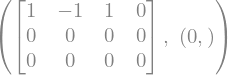

In [7]:
(A - 1*sy.eye(3)).row_join(sy.zeros(3,1)).rref()

The null space is the solution set of the linear system.

$$
\left[
\begin{matrix}
x_1 \\ x_2 \\ x_3
\end{matrix}
\right]=
\left[
\begin{matrix}
x_2-x_3 \\ x_2 \\ x_3
\end{matrix}
\right]=
x_2\left[
\begin{matrix}
1 \\ 1 \\ 0
\end{matrix}
\right]
+x_3\left[
\begin{matrix}
-1 \\ 0 \\ 1
\end{matrix}
\right]
$$

This is called _eigenspace_ for $\lambda = 1$, which is a subspace in $\mathbb{R}^3$. All eigenvectors are inside the eigenspace.

We can proceed with $\lambda = 2$ as well.

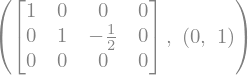

In [8]:
(A - 2*sy.eye(3)).row_join(sy.zeros(3,1)).rref()

The null space is the solution set of the linear system.

$$
\left[
\begin{matrix}
x_1 \\ x_2 \\ x_3
\end{matrix}
\right]=
\left[
\begin{matrix}
0\\ \frac{1}{2}x_3\\ x_3
\end{matrix}
\right]=
x_3\left[
\begin{matrix}
0 \\ \frac{1}{2} \\ 1
\end{matrix}
\right]
$$

To avoid troubles of solving back and forth, SymPy has ```eigenvects``` to calcuate eigenvalues and eigenspaces (basis of eigenspace).

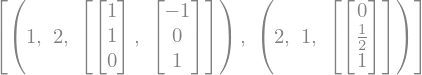

In [9]:
eig = A.eigenvects(); eig

To clarify what we just get, write

In [10]:
print('Eigenvalue = {0}, Multiplicity = {1}, Eigenspace = {2}'.format(eig[0][0], eig[0][1], eig[0][2]))

Eigenvalue = 1, Multiplicity = 2, Eigenspace = [Matrix([
[1],
[1],
[0]]), Matrix([
[-1],
[ 0],
[ 1]])]


In [11]:
print('Eigenvalue = {0}, Multiplicity = {1}, Eigenspace = {2}'.format(eig[1][0], eig[1][1], eig[1][2]))

Eigenvalue = 2, Multiplicity = 1, Eigenspace = [Matrix([
[  0],
[1/2],
[  1]])]


## <font face="gotham" color="black"> NumPy Functions for Eigenvalues and Eigenspace

```.eigvals()``` and ```.eig(A)``` are NumPy functions for eigenvalues and eigenvectors.

In [12]:
matrix = np.array([
             [1,2],
             [3,4]
             ])

# get the eigenvalues
evals = np.linalg.eig(matrix)[0]
evals

array([-0.372,  5.372])

In [13]:
# Finding eigenvectors

evals,evecs = np.linalg.eig(matrix)
print(evals), print(' ')
print(evecs)

[-0.372  5.372]
 
[[-0.825 -0.416]
 [ 0.566 -0.909]]


In [14]:
# same matrix as above
evals,evecs = np.linalg.eig(matrix)

print('List of eigenvalues:')
print(evals)

print(f'\nMatrix of eigenvectors (in the columns!):')
print(evecs)

List of eigenvalues:
[-0.372  5.372]

Matrix of eigenvectors (in the columns!):
[[-0.825 -0.416]
 [ 0.566 -0.909]]


# Geometry of eigenvectors

[-0.618  1.618]


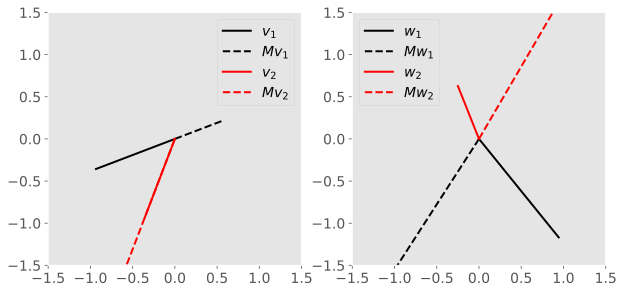

In [15]:
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

# in 2D of course, for visualization

# the matrix
M = np.array([ [-1,1],
               [-1,2] ])

# its eigenvalues and eigenvectors
eigenvalues,eigenvectors = np.linalg.eig(M)
print(eigenvalues)

# some random vectors
notEigenvectors = np.random.randn(2,2)

# multipy to create new vectors
Mv = M @ eigenvectors
Mw = M @ notEigenvectors



## and now plot
_,axs = plt.subplots(1,2,figsize=(10,6))

# the two eigenvectors
axs[0].plot([0,eigenvectors[0,0]],[0,eigenvectors[1,0]],'k',linewidth=2,label='$v_1$')
axs[0].plot([0,Mv[0,0]],[0,Mv[1,0]],'k--',linewidth=2,label='$Mv_1$')

axs[0].plot([0,eigenvectors[0,1]],[0,eigenvectors[1,1]],'r',linewidth=2,label='$v_2$')
axs[0].plot([0,Mv[0,1]],[0,Mv[1,1]],'r--',linewidth=2,label='$Mv_2$')

# the two non-eigenvectors
axs[1].plot([0,notEigenvectors[0,0]],[0,notEigenvectors[1,0]],'k',linewidth=2,label='$w_1$')
axs[1].plot([0,Mw[0,0]],[0,Mw[1,0]],'k--',linewidth=2,label='$Mw_1$')

axs[1].plot([0,notEigenvectors[0,1]],[0,notEigenvectors[1,1]],'r',linewidth=2,label='$w_2$')
axs[1].plot([0,Mw[0,1]],[0,Mw[1,1]],'r--',linewidth=2,label='$Mw_2$')


# adjust the graphs a bit
for i in range(2):
  axs[i].axis('square')
  axs[i].set_xlim([-1.5,1.5])
  axs[i].set_ylim([-1.5,1.5])
  axs[i].grid()
  axs[i].legend()

#plt.savefig('Figure_13_01.png',dpi=300)
plt.show()

## Visualizing linear transformations

We can see the effect of eigenvectors and eigenvalues in linear transformation. We will see first how linear transformation works. Linear transformation is a mapping between an input vector and an output vector. Different operations like projection or rotation are linear transformations.

-------

 Every linear transformations can be though as applying a matrix on the input vector. We will see the meaning of this graphically. For that purpose, let's start by drawing the set of unit vectors (they are all vectors with a norm of 1).

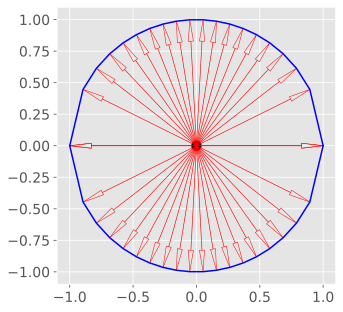

In [16]:
x = np.linspace(-1, 1, 20)
y_u = np.sqrt(1 - x**2)
y_d = -np.sqrt(1 - x**2)

fig, ax = plt.subplots(figsize = (5, 5))
ax.plot(x, y_u, color = 'b')
ax.plot(x, y_d, color = 'b')

ax.scatter(0, 0, s = 100, fc = 'k', ec = 'r')

for i in range(len(x)):
    ax.arrow(0, 0, x[i], y_u[i], head_width = .04,
             head_length= .17, length_includes_head = True,
             width = .001, ec = 'r', fc = 'None')
    ax.arrow(0, 0, x[i], y_d[i], head_width = .04,
             head_length= .17, length_includes_head = True,
             width = .001, ec = 'r', fc = 'None')

Then, we will transform each of these points by applying a matrix
. This is the goal of the function bellow that takes a matrix as input and will draw

1. the origin set of unit vectors
2. the transformed set of unit vectors
3. the eigenvectors
4. the eigenvectors scalled by their eigenvalues

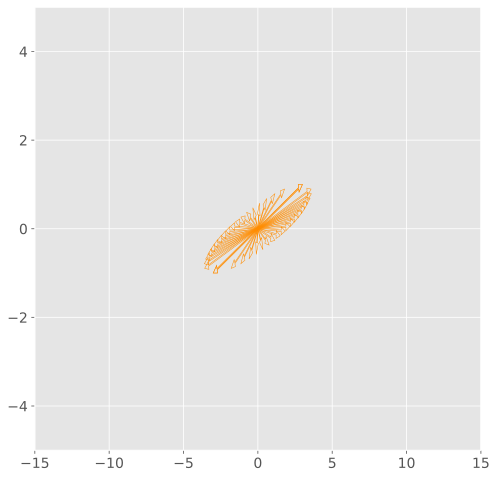

In [17]:
A = np.array([[3, -2], [1, 0]])

Vu = np.hstack((x[:, np.newaxis], y_u[:, np.newaxis]))
AV_u = (A@Vu.T)

Vd = np.hstack((x[:, np.newaxis], y_d[:, np.newaxis]))
AV_d = (A@Vd.T)

fig, ax = plt.subplots(figsize = (8, 8))

for i in range(len(x)):
    ax.arrow(0, 0, AV_u[0, i], AV_u[1, i], head_width = .18,
             head_length= .27, length_includes_head = True,
             width = .03, ec = 'darkorange', fc = 'None')
    ax.arrow(0, 0, AV_d[0, i], AV_d[1, i], head_width = .18,
             head_length= .27, length_includes_head = True,
             width = .03, ec = 'darkorange', fc = 'None')
ax.axis([-15, 15, -5, 5])
plt.show()

We can plot the cirle and ellipse together, those vectors pointing the same direction before and after the linear transformation are eigenvector of $A$, eigenvalue is the length ratio between them.

In [18]:
def plotVectors(vecs, cols, alpha=1):
    """
    Plot set of vectors.

    Parameters
    ----------
    vecs : array-like
        Coordinates of the vectors to plot. Each vectors is in an array. For
        instance: [[1, 3], [2, 2]] can be used to plot 2 vectors.
    cols : array-like
        Colors of the vectors. For instance: ['red', 'blue'] will display the
        first vector in red and the second in blue.
    alpha : float
        Opacity of vectors

    Returns:

    fig : instance of matplotlib.figure.Figure
        The figure of the vectors
    """
    plt.axvline(x=0, color='#A9A9A9', zorder=0)
    plt.axhline(y=0, color='#A9A9A9', zorder=0)

    for i in range(len(vecs)):
        if (isinstance(alpha, list)):
            alpha_i = alpha[i]
        else:
            alpha_i = alpha
        x = np.concatenate([[0,0],vecs[i]])
        plt.quiver([x[0]],
                   [x[1]],
                   [x[2]],
                   [x[3]],
                   angles='xy', scale_units='xy', scale=1, color=cols[i],
                  alpha=alpha_i)

def linearTransformation(transformMatrix):
    orange = '#FF9A13'
    blue = '#1190FF'
    # Create original set of unit vectors
    t = np.linspace(0, 2*np.pi, 100)
    x = np.cos(t)
    y = np.sin(t)

    # Calculate eigenvectors and eigenvalues
    eigVecs = np.linalg.eig(transformMatrix)[1]
    eigVals = np.diag(np.linalg.eig(transformMatrix)[0])

    # Create vectors of 0 to store new transformed values
    newX = np.zeros(len(x))
    newY = np.zeros(len(x))
    for i in range(len(x)):
        unitVector_i = np.array([x[i], y[i]])
        # Apply the matrix to the vector
        newXY = transformMatrix.dot(unitVector_i)
        newX[i] = newXY[0]
        newY[i] = newXY[1]

    plotVectors([eigVecs[:,0], eigVecs[:,1]],
                cols=[blue, blue])
    plt.plot(x, y)

    plotVectors([eigVals[0,0]*eigVecs[:,0], eigVals[1,1]*eigVecs[:,1]],
                cols=[orange, orange])
    plt.plot(newX, newY)
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.axis('equal')
    plt.show()

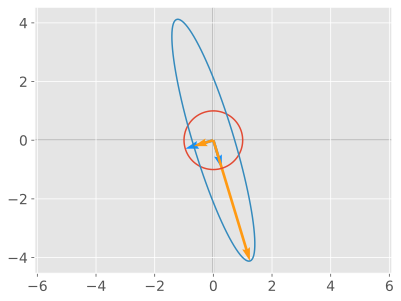

In [19]:
A = np.array([[1,-1], [-1, 4]])
linearTransformation(A)

We can see the unit circle in dark blue, the non scaled eigenvectors in light blue, the transformed unit circle in green and the scaled eigenvectors in yellow.

It is worth noting that the eigenvectors are orthogonal here because the matrix is symmetric. Let's try with a non-symmetric matrix:

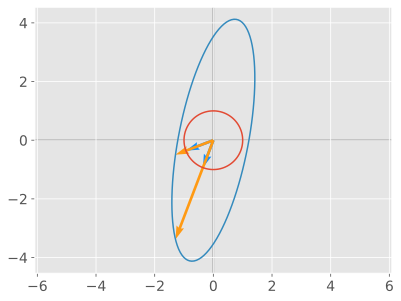

In [20]:
A = np.array([[1,1], [-1, 4]])
linearTransformation(A)

In this case, the eigenvectors are not orthogonal!

Eigenvalues of an Inverse
-------------------------

An invertible matrix cannot have an eigenvalue equal to zero. Furthermore, the eigenvalues of the inverse matrix are equal to the inverse of the eigenvalues of the original matrix:

$$
\mathbf{A} {\bf x} = \lambda {\bf x}\implies \\ \mathbf{A}^{-1} \mathbf{A} {\bf x} = \lambda \mathbf{A}^{-1} {\bf x} \implies \\ {\bf x} = \lambda \mathbf{A}^{-1} {\bf x}\implies \\ \mathbf{A}^{-1} {\bf x} = \frac{1}{\lambda} {\bf x}.
$$


Diagonalizability
-----------------

An $n \times n$ matrix with $n$ linearly independent eigenvectors can be expressed as its eigenvalues and eigenvectors as:

$$
\mathbf{A}\mathbf{X} = \begin{bmatrix} \vert & & \vert \\ \lambda_1 {\bf x}_1 & \dots & \lambda_n {\bf x}_n \\ \vert & & \vert \end{bmatrix} = \begin{bmatrix} \vert & & \vert \\ {\bf x}_1 & \dots & {\bf x}_n \\ \vert & & \vert \end{bmatrix} \begin{bmatrix}\lambda_1 & & \\ & \ddots & \\ & & \lambda_n \end{bmatrix} = \mathbf{X}\mathbf{D}
$$

The eigenvector matrix can be inverted to obtain the following **_similarity transformation_** of $\mathbf{A}$:

$$
\mathbf{AX} = \mathbf{XD} \iff \mathbf{A} = \mathbf{XDX}^{-1} \iff \mathbf{X}^{-1}\mathbf{A}\mathbf{X} = \mathbf{D}
$$

Multiplying the matrix $\mathbf{A}$ by $\mathbf{X}^{-1}$ on the left and $\mathbf{X}$ on the right transforms it into a diagonal matrix; it has been ‘‘diagonalized’’.

#### Example: Matrix that is diagonalizable

A $n \times n$ matrix is diagonalizable if and only if it has $n$ linearly independent eigenvectors. For example:

$$
\overbrace{\begin{bmatrix} 1/6 & -1/3 & 1/6 \\ -1/2 & 0 & 1/2 \\ 1/3 & 1/3 & 1/3 \end{bmatrix}}^{\mathbf{X}^{-1}} \overbrace{\begin{bmatrix} 1 & 1 & 0 \\ 1 & 0 & 1 \\ 0 & 1 & 1 \end{bmatrix}}^{\mathbf{A}} \overbrace{\begin{bmatrix} 1 & -1 & 1 \\ -2 & 0 & 1 \\ 1 & 1 & 1 \end{bmatrix}}^{\mathbf{X}} = \overbrace{\begin{bmatrix} -1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 2 \end{bmatrix}}^{\mathbf{D}}
$$

#### Example: Matrix that is not diagonalizable

A matrix $\mathbf{A}$ with linearly dependent eigenvectors is not diagonalizable. For example, while it is true that

$$
\overbrace{\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}}^{\mathbf{A}} \overbrace{\begin{bmatrix} 1 & 1 \\ 0 & 0 \end{bmatrix}}^{\mathbf{X}} = \overbrace{\begin{bmatrix} 1 & 1 \\ 0 & 0 \end{bmatrix}}^{\mathbf{X}} \overbrace{\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}}^{\mathbf{D}},
$$

the matrix $\mathbf{X}$ does not have an inverse, so we cannot diagonalize $\mathbf{A}$ by applying an inverse. In fact, for any non-singular matrix $\mathbf{P}$, the product $\mathbf{P}^{-1}\mathbf{AP}$ is not diagonal.

In [21]:
import numpy.linalg as la
def diagonalize(A):
    # A: nxn matrix
    m, n = np.shape(A)
    if (m != n):
      return None

    evals, evecs = la.eig(A) # eigenvectors as columns
    if (la.matrix_rank(evecs) != n):
      return None

    D = np.diag(evals)
    X = evecs
    return (D, X)


matrix = np.array([[1,1,0],
                   [1,0,1],
                   [0,1,1]])
D, X = diagonalize(matrix)
print(D)
print(X)


[[-1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  2.]]
[[ 0.408  0.707  0.577]
 [-0.816  0.     0.577]
 [ 0.408 -0.707  0.577]]


# Real Symmetric Matrix

In the case of real symmetric matrices, the eigendecomposition can be expressed as

$$ {A} = {Q}\Lambda {Q}^\text{T}$$

where $Q$ is the matrix with eigenvectors as columns and $Λ$ is $\text{diag}(\lambda)$



In [22]:
A = np.array([[6, 2], [2, 3]])
A

array([[6, 2],
       [2, 3]])

In [23]:
eigVals, eigVecs = np.linalg.eig(A)
print(eigVals); print(eigVecs)

[7. 2.]
[[ 0.894 -0.447]
 [ 0.447  0.894]]


In [24]:
D = np.diag(eigVals)
print(D)

[[7. 0.]
 [0. 2.]]


In [25]:
eigVecs.dot(D).dot(eigVecs.T)

array([[6., 2.],
       [2., 3.]])

In [26]:
# show that Q'Q=I
np.round( eigVecs.T@eigVecs ,10) # rounded for visibility (precision errors...)

array([[1., 0.],
       [0., 1.]])

In [27]:
# just some random matrix
A = np.random.randint(-3,4,(3,3))

# and make it symmetric
A = A.T@A

# its eigendecomposition
L,Q = np.linalg.eig(A)

# all pairwise dot products
print( np.dot(Q[:,0],Q[:,1]) )
print( np.dot(Q[:,0],Q[:,2]) )
print( np.dot(Q[:,1],Q[:,2]) )

1.1102230246251565e-16
-1.6653345369377348e-16
-3.3306690738754696e-16


In [28]:
# real-valued matrix with complex-valued eigenvalues

# a matrix
A = np.array([[-3, -3, 0],
              [ 3, -2, 3],
              [ 0,  1, 2]])


# btw, random matrices often have complex eigenvalues (though this is not guaranteed):
#A = np.random.randint(-3,4,(3,3))

# its eigendecomposition
L,V = np.linalg.eig(A)
L.reshape(-1,1) # print as column vector

array([[-2.745+2.852j],
       [-2.745-2.852j],
       [ 2.489+0.j   ]])

In [29]:
# a singular matrix
A = np.array([[1,4,7],
              [2,5,8],
              [3,6,9]])

# its eigendecomposition
L,V = np.linalg.eig(A)


# print its rank...
print( f'Rank = {np.linalg.matrix_rank(A)}\n' )

# ... and its eigendecomposition
print('Eigenvalues: ')
print(L.round(2)), print(' ')

print('Eigenvectors:')
print(V.round(2))

Rank = 2

Eigenvalues: 
[16.12 -1.12 -0.  ]
 
Eigenvectors:
[[-0.46 -0.88  0.41]
 [-0.57 -0.24 -0.82]
 [-0.68  0.4   0.41]]


# Generalized eigendecomposition

In [30]:
n = 4

# create symmetric matrices
A = np.random.randn(n,n)
A = A.T@A

# impose a correlation between the two matrices (this improves numerical stability of the simultaneousl diagonalization)
B = np.random.randn(n,n)
B = B.T@B + A/10


# using scipy
from scipy.linalg import eigh
evals,evecs = eigh(A,B)
evals

array([0.   , 0.186, 2.204, 9.998])

Expressing an Arbitrary Vector as a Linear Combination of Eigenvectors
----------------------------------------------------------------------

If an $n\times n$ matrix $\mathbf{A}$ is diagonalizable, then we can write an arbitrary vector as a linear combination of the eigenvectors of $\mathbf{A}$. Let ${\bf u}_1,{\bf u}_2,\dots,{\bf u}_n$ be $n$ linearly independent eigenvectors of $\mathbf{A}$; then an arbitrary vector $\mathbf{x}_0$ can be written:

$$
{\bf x}_0 = \alpha_1 {\bf u}_1 + \alpha_2 {\bf u}_2 + \dots + \alpha_n {\bf u}_n.
$$

If we apply the matrix $\mathbf{A}$ to $\mathbf{x}_0$:

$$
\begin{align} \mathbf{A}{\bf x}_0 &= \alpha_1 \mathbf{A}{\bf u}_1 + \alpha_2\mathbf{A}{\bf u}_2 + \dots + \alpha_n \mathbf{A}{\bf u}_n, \\ &= \alpha_1 \lambda_1 {\bf u}_1 + \alpha_2\lambda_2 {\bf u}_2 + \dots + \alpha_n \lambda_n {\bf u}_n, \\ &= \lambda_1 \left(\alpha_1 {\bf u}_1 + \alpha_2\frac{\lambda_2}{\lambda_1}{\bf u}_2 + \dots + \alpha_n \frac{\lambda_n}{\lambda_1} {\bf u}_n\right). \\ \end{align}
$$

If we repeatedly apply $\mathbf{A}$ we have

$$
\mathbf{A}^k{\bf x}_0= \lambda_1^k \left(\alpha_1 {\bf u}_1 + \alpha_2\left(\frac{\lambda_2}{\lambda_1}\right)^k{\bf u}_2 + \dots + \alpha_n \left(\frac{\lambda_n}{\lambda_1}\right)^k {\bf u}_n\right).
$$

In the case where one eigenvalue has magnitude that is strictly greater than all the others, i.e.

$\vert\lambda_1\vert > \vert\lambda_2\vert\geq \vert\lambda_3\vert \geq \dots \geq\vert\lambda_n\vert$,

this implies

$$
\lim_{k\to\infty}\frac{\mathbf{A}^k {\bf x}_0}{\lambda_1^{k}} = \alpha_1 {\bf u}_1.
$$

This observation motivates the algorithm known as **_power iteration_**, which is the topic of the next section.

Power Iteration algorithm
-------------------------

For a matrix ${\bf A}$, power iteration will find a scalar multiple of an eigenvector ${\bf u}_1$, corresponding to the dominant eigenvalue (largest in magnitude) $\lambda_1$, provided that $\vert\lambda_1\vert$ is strictly greater than the magnitude of the other eigenvalues, i.e., $\vert\lambda_1\vert > \vert\lambda_2\vert \ge \dots \ge \vert\lambda_n\vert$.

Suppose

$\mathbf{x}_0 = \alpha_1 \mathbf{u}_1 + \alpha_2\mathbf{u}_2 + \dots \alpha_n\mathbf{u}_n,\text{ with }\alpha_1 \neq 0$.

From the previous section, the iterative sequence

$$
\mathbf{x}_k = \mathbf{A}\mathbf{x}_{k-1}\text{ for }k=1,2,3,\dots
$$

satisfies

$\mathbf{x}_k = \mathbf{A}^k\mathbf{x}_0 \implies \lim_{k\to\infty}\frac{\mathbf{x}_k}{\lambda_1^k} = \alpha_1\mathbf{u}_1$.

Thus, for large $k$, $\mathbf{x}_k\approx \lambda_1^k \alpha_1\mathbf{u}_1$. Unfortunately, this mean that $\|\mathbf{x}_k\| \approx |\lambda_1|^k\cdot\|\alpha_1\mathbf{u}_1\|,$ which will be very large if $|\lambda_1| > 1$, or very small if $ |\lambda_1| < 1 $. For this reason, we use **_normalized_** power iteration.

Normalized power iteration, is given by the following. Let $\mathbf{x}_0$ be a vector with unit norm: $\|\mathbf{x}_0\| = 1$ (any norm is fine), with $\mathbf{x}_0 = \alpha_1 \mathbf{u}_1 + \alpha_2\mathbf{u}_2 + \dots \alpha_n\mathbf{u}_n,\text{ and }\alpha_1 \neq 0$.

**_Normalized power iteration_** is defined by the following iterative sequence for $k=1,2,3,\dots$:

$$
\begin{align} &\mathbf{y}_k = \mathbf{A}\mathbf{x}_{k-1} \\ &\mathbf{x}_k = \frac{\mathbf{y}_k}{\|\mathbf{y}_k\|} \end{align}
$$

where the norm $\|\cdot\|$ is identical to the norm used when we assumed $\|\mathbf{x}_0\| = 1$.

It can be shown that this sequence satisfies

$$
\mathbf{x}_k = \frac{\mathbf{A}^k\mathbf{x}_0}{\|\mathbf{A}^k\mathbf{x}_0\|}.
$$

This means that for large values of $k$, we have

$$
\mathbf{x}_k \approx \left(\frac{\lambda_1}{|\lambda_1|}\right)^k\cdot\frac{\alpha_1\mathbf{u}_1}{\|\alpha_1\mathbf{u}_1\|}.
$$

The largest eigenvalue could be positive, negative, or a complex number. In each case we will have:

$$
\begin{align} \lambda_1 > 0 \implies &\mathbf{x}_k \approx \frac{\alpha_1\mathbf{u}_1}{\|\alpha_1\mathbf{u}_1\|}\hspace{22.5mm} \mathbf{x}_k\text{ converges} \\ \lambda_1 < 0 \implies &\mathbf{x}_k \approx (-1)^k \frac{\alpha_1\mathbf{u}_1}{\|\alpha_1\mathbf{u}_1\|}\hspace{11.5mm} \text{in the limit, }\mathbf{x}_k\text{ alternates between }\pm\frac{\alpha_1\mathbf{u}_1}{\|\alpha_1\mathbf{u}_1\|}\\ \lambda_1 = re^{i\theta} \implies & \mathbf{x}_k \approx e^{ik\theta} \frac{\alpha_1\mathbf{u}_1}{\|\alpha_1\mathbf{u}_1\|} \hspace{16mm} \text{in the limit, }\mathbf{x}_k \text{ is a scalar multiple of } \mathbf{u}_1 \text{ with coefficient that rotates around the unit circle}. \end{align}
$$

Strictly speaking, normalized power iteration only converges to a single vector if $\lambda_1 > 0$, but $\mathbf{x}_k$ will be close to a scalar multiple of the eigenvector $\mathbf{u}_1$ for large values of $k$, regardless of whether the dominant eigenvalue is positive, negative, or complex. So normalized power iteration will work for any value of $\lambda_1$, as long as it is strictly bigger in magnitude than the other eigenvalues.

Power Iteration code
--------------------

The following code snippet performs power iteration:

    import numpy as np
    def power_iter(A, x_0, p):
      # A: nxn matrix, x_0: initial guess, p: type of norm
      x_0 = x_0/np.linalg.norm(x_0,p)
      x_k = x_0
      for i in range(max_iterations):
        y_k = A @ x_k
        x_k = y_k/np.linalg.norm(y_k,p)
      return x_k
    

#### Example: Two Steps of Power Iteration

We’ll use normalized power iteration (with the infinity norm) to approximate an eigenvector of the following matrix: $\mathbf{A} = \begin{bmatrix} 1 & -2 \\ -1 & 1 \end{bmatrix},$ and the following initial guess: $\mathbf{x}_0 = \begin{bmatrix} -1 \\ 0 \end{bmatrix}$

**First Iteration**:

$$
 \begin{align} &\mathbf{y}_1 = \mathbf{A}\mathbf{x}_0 = \begin{bmatrix} 1 & -2 \\ -1 & 1 \end{bmatrix} \begin{bmatrix} -1 \\ 0 \end{bmatrix} = \begin{bmatrix} -1 \\ 1 \end{bmatrix},\\[15pt] &\mathbf{x}_1 = \frac{\mathbf{y}_1}{\|\mathbf{y}_1\|_{\infty}} = \mathbf{y}_1 = \begin{bmatrix} -1 \\ 1\end{bmatrix}. \end{align}
$$

**Second Iteration**:

$$
\begin{align} &\mathbf{y}_2 = \mathbf{A}\mathbf{x}_1 = \begin{bmatrix} 1 & -2 \\ -1 & 1 \end{bmatrix} \begin{bmatrix} -1 \\ 1 \end{bmatrix} = \begin{bmatrix} -3 \\ 2 \end{bmatrix},\\[15pt] &\mathbf{x}_2 = \frac{\mathbf{y}_2}{\|\mathbf{y}_2\|_{\infty}} = \frac{1}{3}\mathbf{y}_2= \begin{bmatrix} -1 \\ \frac{2}{3}\end{bmatrix} = \begin{bmatrix} -1 \\ 0.6666\dots\end{bmatrix}. \end{align}
$$

Even after only two iterations, we are getting close to a corresponding eigenvector:

$$
\mathbf{u}_1 = \begin{bmatrix} -1 \\ \frac{1}{\sqrt{2}} \end{bmatrix} \approx \begin{bmatrix} -1 \\ 0.7071 \end{bmatrix}
$$

with relative error about 4 percent when measured in the infinity norm.

Computing Eigenvalues from Eigenvectors
---------------------------------------

Power iteration allows us to find an approximate eigenvector corresponding to the largest eigenvalue in magnitude. How can we compute the actual eigenvalue from this? If $\lambda \text{ is an eigenvalue of }\mathbf{A} \text{, with corresponding eigenvector } \mathbf{u}$, then we can compute the value of $\lambda$ using the **_Rayleigh Quotient_**:

$$
\lambda = \frac{\mathbf{u}^T\mathbf{A}\mathbf{u}}{\mathbf{u}^T\mathbf{u}}.
$$

Thus, one can compute an approximate eigenvalue using the approximate eigenvector found during power iteration.

Power Iteration and Floating-Point Arithmetic
---------------------------------------------

Recall that we made the assumption that the initial guess satisfies

$\mathbf{x}_0 = \alpha_1 \mathbf{u}_1 + \alpha_2\mathbf{u}_2 + \dots \alpha_n\mathbf{u}_n,\text{ with }\alpha_1 \neq 0$.

What happens if we choose an initial guess where $\alpha_1 = 0$? If we further assume that $\vert\lambda_2\vert > \vert\lambda_3\vert\geq \vert\lambda_4\vert \geq \dots \geq\vert\lambda_n\vert$, then in theory

$$
\mathbf{A}^k\boldsymbol{x}_0= \lambda_2^k \left(\alpha_2 {\bf u}_2 + \alpha_3\left(\frac{\lambda_3}{\lambda_2}\right)^k{\bf u}_3 + \dots + \alpha_n \left(\frac{\lambda_n}{\lambda_2}\right)^k {\bf u}_n\right),
$$

and we would expect that

$$
\lim_{k\to\infty}\frac{\mathbf{A}^k \boldsymbol{x}_0}{\lambda_2^{k}} = \alpha_2 {\bf u}_2.
$$

In practice, this does not happen. For one thing, choosing an initial guess such that $\alpha_1 = 0$ is extremely unlikely if we have no prior knowledge about the eigenvector $\mathbf{u}_1$. Since power iteration is performed numerically, using finite precision arithmetic, we will encounter the presence of rounding error in every iteration. This means that at every iteration $k\text{, including }k = 0$, we will instead have

$$
\mathbf{A}^k\hat{\boldsymbol{x}}_0= \lambda_1^k \left(\hat{\alpha}_1 \boldsymbol{u}_1 + \hat{\alpha}_2\left(\frac{\lambda_2}{\lambda_1}\right)^k\boldsymbol{u}_2 + \dots + \hat{\alpha}_n \left(\frac{\lambda_n}{\lambda_1}\right)^k \boldsymbol{u}_n\right),
$$

where the $\hat{\alpha}_k$ are the approximate expansion coefficients of the rounded result. Even if $\alpha_1 = 0$, the finite precision representation $\hat{\mathbf{x}}_0$, will very likely have expansion coefficient $\hat{\alpha}_1 \neq 0$. Even in the case where rounding the initial guess does not introduce a non-zero $\hat{\alpha}_1$, rounding after applying the matrix $\mathbf{A}$ will almost certainly introduce a non-zero component in the dominant eigenvector after enough iterations. The probability of coming up with a starting guess $\mathbf{x}_0$ such that $\hat{\alpha}_1 = 0$ for all iterations is very, very low, if not impossible.

Power Iteration without a Dominant Eigenvalue
---------------------------------------------

Above, we assumed that one eigenvalue had magnitude strictly larger than all the others: $\vert\lambda_1\vert > \vert\lambda_2\vert\geq \vert\lambda_3\vert \geq \dots \geq\vert\lambda_n\vert$. What happens if $\vert\lambda_1\vert = \vert\lambda_2\vert$?

If $\lambda_1 = \lambda_2 = \lambda \in \mathbb{R}$, then:

$$
\mathbf{x}_k = \mathbf{A}^k\mathbf{x}_0 \approx \alpha_1\lambda^k\mathbf{u}_1 + \alpha_2\lambda^k\mathbf{u}_2 = \lambda^k\left(\alpha_1\mathbf{u}_1 + \alpha_2\mathbf{u}_2\right),
$$

hence

$\lim_{k\to\infty}\lambda^{-k}\mathbf{A}^k\mathbf{x}_0 = \alpha_1\mathbf{u}_1 + \alpha_2\mathbf{u}_2$.

The quantity $\alpha_1\mathbf{u}_1 + \alpha_2\mathbf{u}_2$ is still an eigenvector corresponding to $\lambda$, so power iteration will still approach a dominant eigenvector.

If the dominant eigenvalues have opposite sign, i.e., $\lambda_1 = -\lambda_2 = \lambda \in \mathbb{R}$, then

$$
\mathbf{x}_k = \mathbf{A}^k\mathbf{x}_0 \approx \alpha_1\lambda^k\mathbf{u}_1 + \alpha_2(-\lambda)^k\mathbf{u}_2 = \lambda^k\left(\alpha_1\mathbf{u}_1 + (-1)^k\alpha_2\mathbf{u}_2\right).
$$

For large $k$, we will have $\lambda^{-k}\mathbf{A}\mathbf{x}_0 \approx \alpha_1\mathbf{u}_1 + (-1)^k\alpha_2\mathbf{u}_2$, which although is a linear combination of two eigenvectors, is **_not_** itself an eigenvector of $\mathbf{A}$.

Finally, if the two dominant eigenvalues are a complex-conjugate pair $\lambda_1 = re^{i\theta},\ \lambda_2 = re^{-i\theta}$, then $\mathbf{x}_k = \mathbf{A}^k\mathbf{x}_0 \approx \alpha_1\lambda^k\mathbf{u}_1 + \alpha_2(\overline{\lambda})^k\mathbf{u}_2 = \lambda^k\left(\alpha_1\mathbf{u}_1 + \left(\frac{\overline{\lambda}}{\lambda}\right)^k\alpha_2\mathbf{u}_2\right) = \lambda^k(\alpha_1\mathbf{u}_1 + \alpha_2 e^{-i2k\theta}\mathbf{u}_2).$

For large $k$, $\lambda^{-k}\mathbf{A}\mathbf{x}_0$ approximate a linear combination of two eigenvectors, but this linear combination will not itself be an eigenvector.

Inverse Iteration
-----------------

To obtain an eigenvector corresponding to the **_smallest_** eigenvalue $\lambda_n$ of a non-singular matrix, we can apply power iteration to $\mathbf{A}^{-1}$. The following recurrence relationship describes inverse iteration algorithm: $\boldsymbol{x}_{k+1} = \frac{\mathbf{A}^{-1} \boldsymbol{x}_k}{\|\mathbf{A}^{-1} \boldsymbol{x}_k\|},$


Convergence properties
----------------------

The convergence rate for power iteration is **_linear_** and the recurrence relationship for the error between the current iterate and a dominant eigenvector is given by: $\mathbf{e}_{k+1} \approx \frac{|\lambda_2|}{|\lambda_1|}\mathbf{e}_k$ The convergence rate for (shifted) inverse iteration is also linear, but now depends on the two closest eigenvalues to the shift $\sigma$. (Standard inverse iteration corresponds to a shift $\sigma = 0$. The recurrence relationship for the errors is given by: $\mathbf{e}_{k+1} \approx \frac{|\lambda_\text{closest} - \sigma|}{|\lambda_\text{second-closest} - \sigma|}\mathbf{e}_k$



In [31]:
def ray_iter(A, v=None, lam=None, maxiter=1000, tol=1.0e-12):
    m = A.shape[0]
    if v is None:
        v = 2 * np.random.random(m) - 1
    v /= np.linalg.norm(v)
    if lam is None:
        lam = np.dot(v, A @ v)
    print(0, lam)
    for k in range(maxiter):
        B = A - lam * np.eye(A.shape[0])
        w = np.linalg.solve(B, v)
        v = w /np.linalg.norm(w)
        lam = np.dot(v, A @ v)
        print(k+1, lam)
        if np.linalg.norm(A@v - lam*v) < tol:
            return v, lam
    print('Did not converge !!!')
    return v, lam

def power_method(A, v, maxiter=1000, tol=1.0e-12):
    v /= np.linalg.norm(v)
    w = A @ v
    lam = np.dot(v, w)
    print(0, lam)
    for k in range(maxiter):
        v = w /np.linalg.norm(w)
        w = A @ v
        lam = np.dot(v, w)
        print(k+1, lam)
        if np.linalg.norm(A@v - lam*v) < tol:
            return v, lam
    print('Did not converge !!!')
    return v, lam

A = np.array([[2, 1, 1],
              [1, 3, 1],
              [1, 1, 4]])
n = A.shape[0]
v = np.ones(n)
v, lam = power_method(A, v)
# The eigenvalues converge quickly due to quadratic convergence, but eigenvectors converge slowly due to linear convergence.
# The eigenvector closest to v has eigenvalue 5.214319743377534...

print("\n",v)
print("\n")

v = np.array([1., 1., 1.])
v, lam = ray_iter(A, v=v)
print("\n",v)


0 5.000000000000002
1 5.181818181818181
2 5.208192771084338
3 5.213028887981391
4 5.214037052110614
5 5.21425709431699
6 5.214305810348446
7 5.214316641508852
8 5.214319052610872
9 5.214319589534746
10 5.214319709113864
11 5.214319735746317
12 5.214319741677905
13 5.214319742998992
14 5.214319743293228
15 5.214319743358757
16 5.214319743373354
17 5.214319743376604
18 5.214319743377329
19 5.214319743377488
20 5.2143197433775255
21 5.214319743377534
22 5.214319743377535
23 5.214319743377535
24 5.214319743377535
25 5.214319743377535
26 5.214319743377535
27 5.214319743377535
28 5.214319743377535
29 5.214319743377535
30 5.214319743377535
31 5.214319743377534
32 5.214319743377534
33 5.214319743377535
34 5.214319743377535
35 5.214319743377535
36 5.214319743377535
37 5.214319743377534

 [0.397 0.521 0.756]


0 5.000000000000002
1 5.21311475409836
2 5.214319743184033
3 5.214319743377535

 [0.397 0.521 0.756]


In [32]:
def inv_iter(A, mu, maxiter=1000, tol=1.0e-12):
    v = 2 * np.random.rand(A.shape[0]) - 1
    v /= np.linalg.norm(v)
    lam = np.dot(v, A @ v)
    print(0, lam)
    for k in range(maxiter):
        B = A - mu * np.eye(A.shape[0])
        w = np.linalg.solve(B, v)
        v = w /np.linalg.norm(w)
        lam = np.dot(v, A @ v)
        print(k+1, lam)
        if np.linalg.norm(A@v - lam*v) < tol:
            return v, lam
    print('Did not converge !!!')
    return v, lam

A = np.array([[2, 1, 1],
              [1, 3, 1],
              [1, 1, 4]])
mu = 1.0
v, lam = inv_iter(A, mu)
print(lam)
print("\n",v)
print("\n")

v = 2 * np.random.rand(3) - 1
v, lam = ray_iter(A, v=v)
print("\n",v)
print("\n")

v, lam = ray_iter(A, lam=3.0)
print("\n",v)
print("\n")


0 3.328515954807541
1 1.755952029370676
2 1.3506698126296737
3 1.3261410518927585
4 1.3249319132795692
5 1.324872233583188
6 1.3248692829493778
7 1.3248691370257748
8 1.3248691298088535
9 1.3248691294519248
10 1.324869129434273
11 1.324869129433399
12 1.324869129433356
13 1.3248691294333539
14 1.3248691294333539
15 1.3248691294333534
16 1.324869129433354
17 1.324869129433354
18 1.3248691294333539
19 1.3248691294333539
20 1.3248691294333539
1.3248691294333539

 [ 0.888 -0.427 -0.172]


0 1.8622952805349677
1 1.6515273456925963
2 1.3936750606615862
3 1.3251732929073465
4 1.3248691294551778
5 1.3248691294333539

 [ 0.888 -0.427 -0.172]


0 3.0
1 2.4954983622418805
2 2.460813429007055
3 2.460811127189111


LinAlgError: Singular matrix

Orthogonal Matrices
-------------------

Square matrices are called _orthogonal_ if and only if the columns are mutually orthogonal to one another and have a norm of $1$ (such a set of vectors are formally known as a _orthonormal_ set), i.e.: $\boldsymbol{c}_i^T \boldsymbol{c}_j = 0 \quad \forall \ i \neq j, \quad \|\boldsymbol{c}_i\| = 1 \quad \forall \ i \iff \mathbf{A} \in \mathcal{O}(n),$ or $\langle\boldsymbol{c}_i,\boldsymbol{c}_j \rangle = \begin{cases} 0 \quad \mathrm{if} \ i \neq j, \\ 1 \quad \mathrm{if} \ i = j \end{cases} \iff \mathbf{A} \in \mathcal{O}(n),$ where $\mathcal{O}(n)$ is the set of all $n \times n$ orthogonal matrices called the orthogonal group, $\boldsymbol{c}_i$, $i=1, \dots, n$, are the columns of $\mathbf{A}$, and $\langle \cdot, \cdot \rangle$ is the inner product operator. Orthogonal matrices have many desirable properties: $\mathbf{A}^T \in \mathcal{O}(n) \\ \mathbf{A}^T \mathbf{A} = \mathbf{A} \mathbf{A}^T = \mathbf{I} \implies \mathbf{A}^{-1} = \mathbf{A}^T \\ \det{\mathbf{A}} = \pm 1 \\ \kappa_2(\mathbf{A}) = 1$

Gram-Schmidt
------------

The algorithm to construct an orthogonal basis from a set of linearly independent vectors is called the Gram-Schmidt process. For a basis set $\{x_1, x_2, \dots x_n\}$, we can form a orthogonal set $\{v_1, v_2, \dots v_n\}$ given by the following transformation:
$$  \begin{align} \boldsymbol{v}_1 &= \boldsymbol{x}_1, \\ \boldsymbol{v}_2 &= \boldsymbol{x}_2 - \frac{\langle\boldsymbol{v}_1,\boldsymbol{x}_2\rangle}{\|\boldsymbol{v}_1\|^2}\boldsymbol{v}_1\\ \boldsymbol{v}_3 &= \boldsymbol{x}_3 - \frac{\langle\boldsymbol{v}_1,\boldsymbol{x}_3\rangle}{\|\boldsymbol{v}_1\|^2}\boldsymbol{v}_1 - \frac{\langle\boldsymbol{v}_2,\boldsymbol{x}_3\rangle}{\|\boldsymbol{v}_2\|^2}\boldsymbol{v}_2\\ \vdots &= \vdots\\ \boldsymbol{v}_n &= \boldsymbol{x}_n - \sum_{i=1}^{n-1}\frac{\langle\boldsymbol{v}_i,\boldsymbol{x}_n\rangle}{\|\boldsymbol{v}_i\|^2}\boldsymbol{v}_i, \end{align}$$
 where $\langle \cdot, \cdot \rangle$ is the inner product operator. Each of the vectors in the orthogonal set can be normalized independently to obtain a orthonormal basis.


### Pseudocode for Gram-Schmidt

Given a matrix $\mathbf{A} = \begin{bmatrix} \vec{x}_1 \vert \vec{x}_2 \vert \ldots \vert \vec{x}_n \end{bmatrix}$

| Steps |     |
| --:   | :-- |
| 1.    | For  $j=1, 2, \ldots, n$ do Step 2-3
| 2.    | $\phantom{--}$ Set  $\vec{v}_j=\vec{x}_j$
| 3.    | For  $j=1, 2, \ldots, n$ do Step 4-5
| 4.    | $\phantom{--}$ Set  $\vec{q}_j=\vec{v}_j / \vert \vec{v}_j \vert$
| 5.    | $\phantom{--}$ For  $k=j+1, 2, \ldots, n$ do Step 6
| 6.    | $$\phantom{----} \vec{v}_k=\vec{v}_k-\left(\vec{q}^\intercal_k \vec{v}_j\right)\vec{q}_k$$

### Python/NumPy implementation of Gram-Schmidt

In [ ]:
def gram_schmidt(A):
    m, n = A.shape
    Q, R = np.empty((m,n)), np.zeros((n,n))
    for j in range(n):
        v = A[:,j]
        for i in range(j):
            R[i,j] = Q[:,i].dot(A[:,j])
            v = v - R[i,j] * Q[:,i]
        R[j,j] = np.linalg.norm(v, ord=2)
        Q[:,j] = v / R[j,j]
    return Q, R

In [ ]:
m, n = 10, 5
A = 2 * np.random.rand(m,n) - 1
Q, R = gram_schmidt(A)
np.abs(A - Q @ R).max()

In [ ]:
np.abs(Q.T @ Q - np.eye(n)).max()
print(Q.T @ Q)

## QR Factorization

Let $\mathbf{A}$ be any real matrix with linearly independent columns. Then there exists an orthogonal matrix $\mathbf{A}$ triangular matrix $\mathbf{A}$ having non-negative entries on the main diagonal such that: $\mathbf{A=QR}$.


Recall that $\mathbf{Q}^{-1}$ = $\mathbf{Q}^{T}$, we have
$$
\mathbf{R} = \mathbf{Q}^{T}\mathbf{A}
$$

## QR Algorithm for computing eigenvalues

This algorithm is so simple: we start with a matrix $\mathbf{A}^{(0)}$ and perform $\mathbf{QR}$ factorization,

$$\mathbf{A}^{(0)} = \mathbf{Q}^{(0)}\mathbf{R}^{(0)}$$

Then we reverse the factors to form the matrix $\mathbf{A}^{(1)}$,

$$\mathbf{A}^{(1)} = \mathbf{R}^{(0)}\mathbf{Q}^{(0)}$$

We can do this because $\mathbf{A}^{(1)}$ is similar to $\mathbf{A}^{(0)}$, we can verify

$$\mathbf{Q}^{(0)^{-1}}\mathbf{A}^{(0)}\mathbf{Q}^{(0)} = \mathbf{Q}^{(0)^{-1}}(\mathbf{Q}^{(0)}\mathbf{R}^{(0)})\mathbf{Q}^{(0)} = \mathbf{A}^{(1)}$$

And we continue this process without changing the eigenvalues. The above process is called the *unshifted QR algorithm*, and almost always $\mathbf{A}^{(k)}$ approaches a triangular form, its diagonal entries approach its eigenvalues, which are also the eigenalues of $\mathbf{A}^{(0)}$.

### Python/NumPy implementation of QR eigenvalue algorithm

The built in `numpy.linalg` packaged functions to compute eigenvalues use the $\mathbf{QR}$ algorithm; the implementation below simply uses the matrix operations for clarity in the method.

In [33]:
def qr_classical(A, maxiter=1000, tol=1e-12):
    for k in range(maxiter):
        Q, R = np.linalg.qr(A)
        A = R @ Q
        sub_diag = np.diag(A,-1)
        if np.abs(sub_diag).max() < tol:
            print('Converged in iterations = ', k+1)
            return A
    print('Did not converge in maxiter =', maxiter)
    return A

In [34]:
m = 5
B = np.random.random((m,m))
A = 0.5 * (B + B.T)
evals,evecs = np.linalg.eig(A)
print('Eigenvalues = ', evals)


Eigenvalues =  [ 2.506  0.602 -0.693 -0.251 -0.009]


In [35]:
D = qr_classical(A.copy())
print(np.array_str(D,suppress_small=True))

Converged in iterations =  205
[[ 2.506  0.    -0.     0.     0.   ]
 [ 0.    -0.693 -0.     0.    -0.   ]
 [ 0.    -0.     0.602  0.     0.   ]
 [ 0.    -0.     0.    -0.251 -0.   ]
 [ 0.     0.     0.    -0.    -0.009]]


# Homework 4

**HW4-1:** One interesting property of random matrices is that their complex-valued eigenvalues
are distributed in a circle with a radius proportional to the size of the matrix. Compute 93 random 32 by 32 matrices, extract their eigenvalues, divide by the square root of the matrix size (32), and plot the eigenvalues on the complex plane. What do you observe?

**HW4-2**: The orthonormality of columns of $Q$ is not accurate to machine precision using the Gram-Schmidt algorithm above. Test this on a matrix whose columns are almost parallel and compare with NumPy Gram-Schmidt algorithm:

```python
  A = np.array([[0.70000, 0.70711],
                [0.70001, 0.70711]])
  Q, R = np.linalg.qr(A)
  print('NumPy  QR = ',np.abs(Q.T @ Q - np.eye(2)).max())
  Q, R = gram_schmidt(A)
  print('Classical GS QR = ',np.abs(Q.T @ Q - np.eye(2)).max())
```

First, construct a square matrix $A$ with random singular vectors and widely varying singular values spaced by factors of 2 between $2^{-1}$ and $2^{-80}$:
$$
    A = U S V,
$$
where $S=\textrm{ diag}[2^{-1}, 2^{-2}, \ldots, 2^{-80}]$ and $U,V$ are random unitary matrices generated using NumPy QR factorization. Then use Gram-Schmidt function above to compute the QR factorization of $A$. Then plot the diagonal elements of $R$ produced by the above algorithm and produced by the NumPy QR factorization. Describe your observation.

**HW4-3 (Practical QR with shifts)**: The above classical QR algorithm is really really slow. In this homework, use the following idea to speed up the convergence:

Instead of factoring $A_k$ as $Q_k R_k$,

1. Get the QR factorization $$A_k - s_k I = Q_k R_k$$
2. Set $$A_{k+1} = R_k Q_k + s_k I$$

For simplicity, choose the bottom-right element as a shift $s_k$ to approximate an eigenvalue of $A$, i.e. $s_k = A_k(n-1,n-1)$.

#### Assignment: Add shifts to the QR algorithm and compare the number of iterations with the classical QR algorithm above.